# Sanity Check: CircuitNet-N14 Thermal Map DataLoader (Phase 1, DATA-09)

Visualizes (floorplan, power-map, thermal-label) triples from the train and val splits and logs per-channel statistics.

**Local note:** The main split JSONs use Modal absolute paths (`/data/CircuitNet-N14/...`) only valid on the remote GPU cluster. This notebook uses `data/splits/local_train.json` and `data/splits/local_val.json`, pointing to the 5 Vortex-small designs available locally (Plan 01-02 prototype set). The full 189-design dataset lives on Modal.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.dataset import ThermalDataset

DATA_ROOT   = ".."
INDEX_TRAIN = os.path.join(DATA_ROOT, "data/splits/local_train.json")
INDEX_VAL   = os.path.join(DATA_ROOT, "data/splits/local_val.json")
STATS       = os.path.join(DATA_ROOT, "data/normalization_stats.json")

train_ds = ThermalDataset(INDEX_TRAIN, STATS, training=False)
val_ds   = ThermalDataset(INDEX_VAL,   STATS, training=False)

print(f"train size: {len(train_ds)}, val size: {len(val_ds)}")

train size: 4, val size: 1


In [2]:
N_TRAIN = len(train_ds)
N_VAL   = len(val_ds)

train_loader = DataLoader(train_ds, batch_size=N_TRAIN, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=N_VAL,   shuffle=False)

x_train, y_train = next(iter(train_loader))
x_val,   y_val   = next(iter(val_loader))

print(f"x_train: shape={tuple(x_train.shape)} dtype={x_train.dtype}")
print(f"y_train: shape={tuple(y_train.shape)} dtype={y_train.dtype}")
print(f"x_val:   shape={tuple(x_val.shape)} dtype={x_val.dtype}")
print(f"y_val:   shape={tuple(y_val.shape)} dtype={y_val.dtype}")

assert x_train.shape == (N_TRAIN, 2, 256, 256), f"train input shape: {x_train.shape}"
assert y_train.shape == (N_TRAIN, 1, 256, 256), f"train label shape: {y_train.shape}"
assert x_val.shape   == (N_VAL,   2, 256, 256), f"val input shape: {x_val.shape}"
assert y_val.shape   == (N_VAL,   1, 256, 256), f"val label shape: {y_val.shape}"
print("Shape assertions passed.")

x_train: shape=(4, 2, 256, 256) dtype=torch.float32
y_train: shape=(4, 1, 256, 256) dtype=torch.float32
x_val:   shape=(1, 2, 256, 256) dtype=torch.float32
y_val:   shape=(1, 1, 256, 256) dtype=torch.float32
Shape assertions passed.


In [3]:
def chan_stats(t, name):
    for c in range(t.shape[1]):
        arr = t[:, c].numpy()
        print(f"{name}[ch{c}]: min={arr.min():.4f} max={arr.max():.4f} mean={arr.mean():.4f} std={arr.std():.4f}")

chan_stats(x_train, "x_train (normalized)")
chan_stats(y_train, "y_train (raw temperature K)")

x_train (normalized)[ch0]: min=-0.9758 max=6.7045 mean=-0.0017 std=0.8803
x_train (normalized)[ch1]: min=-0.3998 max=7.2604 mean=-0.0037 std=0.7971
y_train (raw temperature K)[ch0]: min=382.4600 max=382.8000 mean=382.6373 std=0.0844


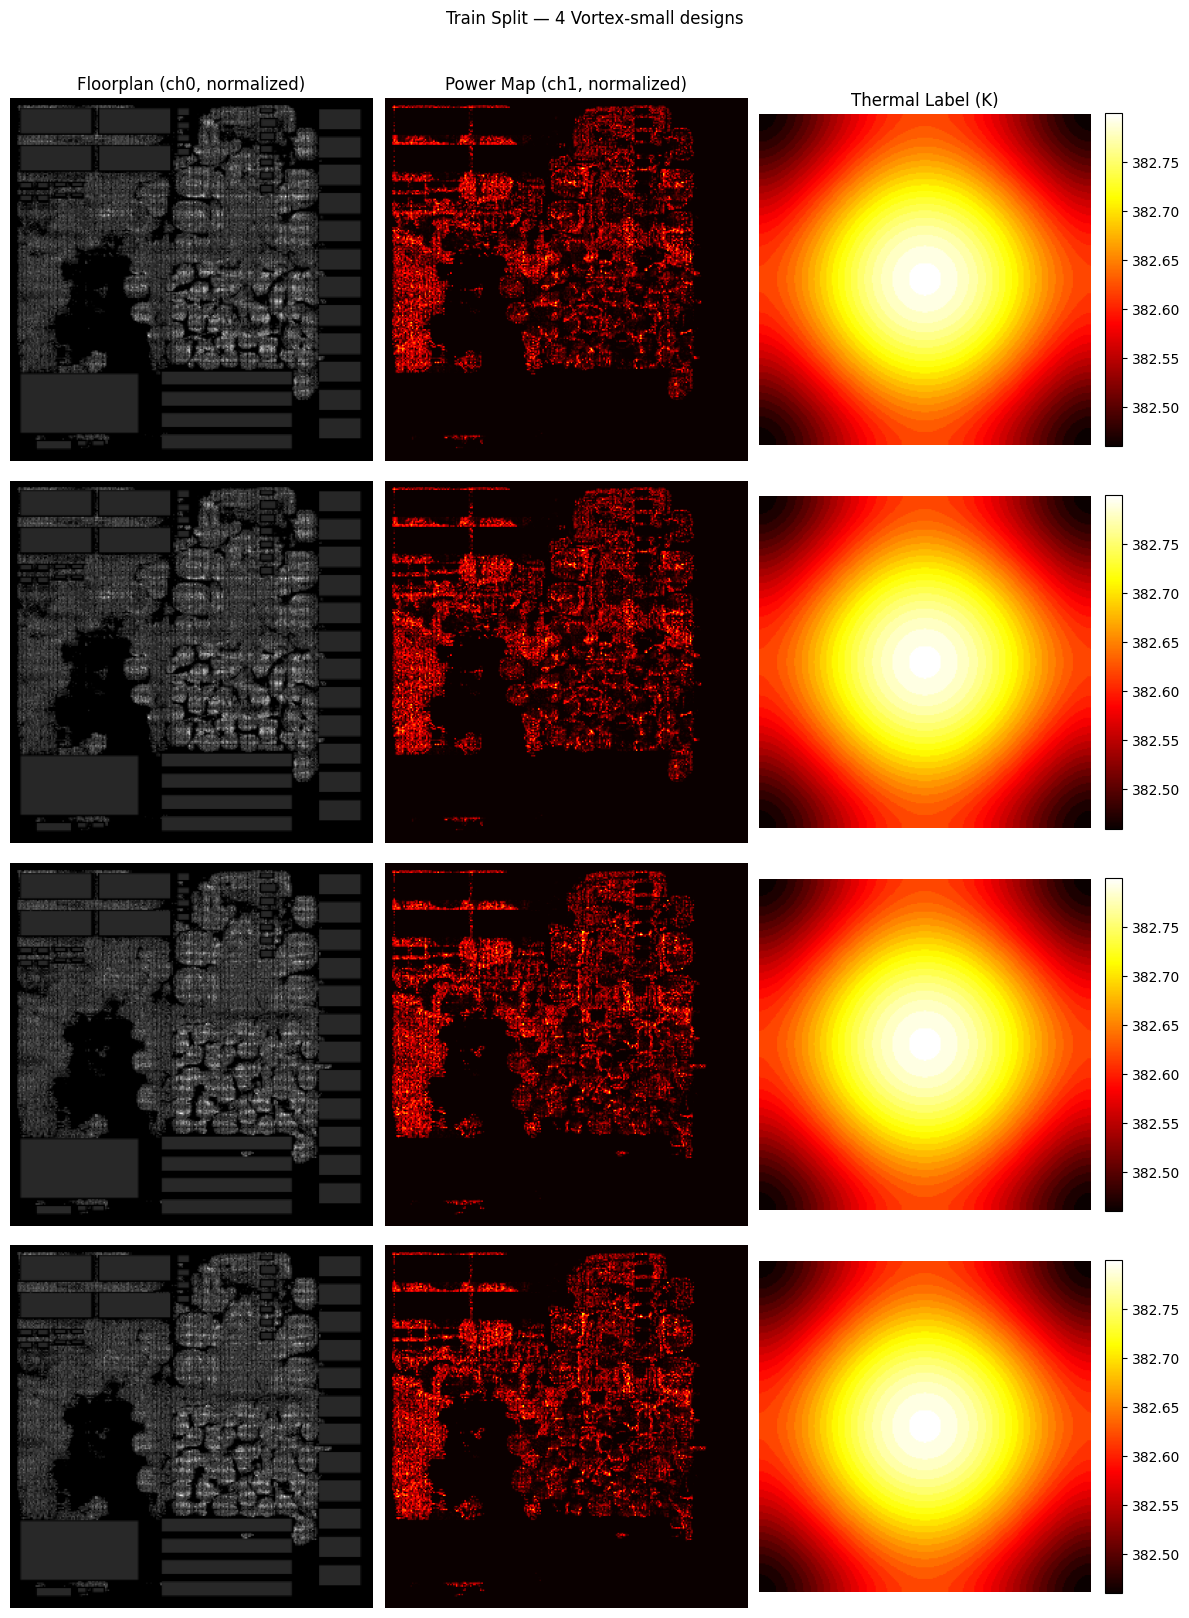

In [4]:
titles = ["Floorplan (ch0, normalized)", "Power Map (ch1, normalized)", "Thermal Label (K)"]
fig, axes = plt.subplots(N_TRAIN, 3, figsize=(12, 4 * N_TRAIN))
if N_TRAIN == 1:
    axes = axes[np.newaxis, :]

for i in range(N_TRAIN):
    axes[i, 0].imshow(x_train[i, 0].numpy(), cmap="gray")
    axes[i, 1].imshow(x_train[i, 1].numpy(), cmap="hot")
    im2 = axes[i, 2].imshow(y_train[i, 0].numpy(), cmap="hot")
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)
    for j, t in enumerate(titles):
        axes[i, j].set_title(t if i == 0 else "")
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(f"Sample {i}", fontsize=9)

plt.suptitle("Train Split — 4 Vortex-small designs", y=1.01)
plt.tight_layout()
plt.show()

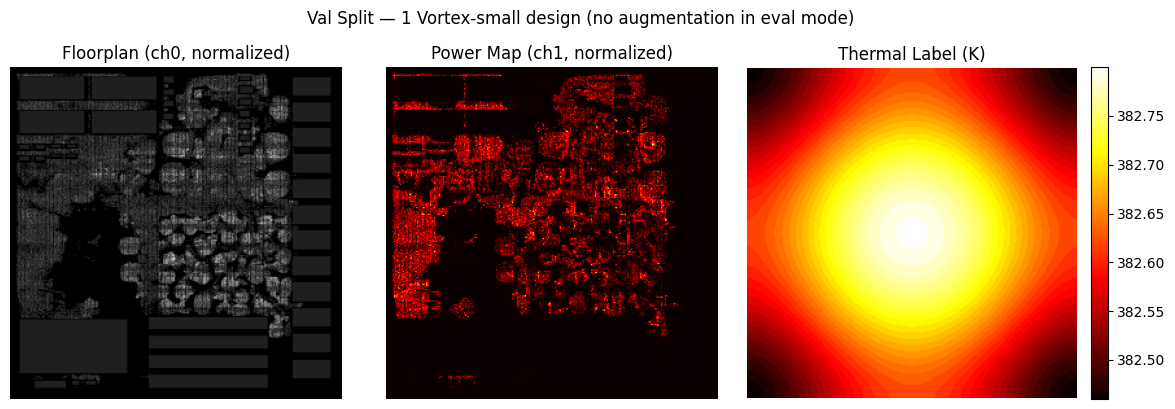

In [5]:
fig, axes = plt.subplots(N_VAL, 3, figsize=(12, 4 * N_VAL))
if N_VAL == 1:
    axes = axes[np.newaxis, :]

for i in range(N_VAL):
    axes[i, 0].imshow(x_val[i, 0].numpy(), cmap="gray")
    axes[i, 1].imshow(x_val[i, 1].numpy(), cmap="hot")
    im2 = axes[i, 2].imshow(y_val[i, 0].numpy(), cmap="hot")
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)
    for j, t in enumerate(titles):
        axes[i, j].set_title(t if i == 0 else "")
        axes[i, j].axis("off")

plt.suptitle("Val Split — 1 Vortex-small design (no augmentation in eval mode)", y=1.01)
plt.tight_layout()
plt.show()